# Lab 7 - krzywe sklejane


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def bspline0(T, t, M):
    """Dyskretna reprezentacja bazowych funkcji B-sklejanych stopnia 0.

    Parametry
    ---------
    T : array-like
        Wektor węzłów o M + 1 wartościach, w tym 0 i 1.
    t : array-like
        Punkty próbkowania z przedziału [0, 1].
    M : int
        Liczba bazowych funkcji stopnia 0.

    Zwraca
    -------
    numpy.ndarray
        Tablica o kształcie (len(t), M) z próbkowanymi funkcjami bazowymi.
    """
    T = np.asarray(T)
    t = np.asarray(t)

    poly0 = np.zeros((t.size, M), dtype=int)
    for j in range(M):
        poly0[:, j] = ((t >= T[j]) & (t < T[j + 1])).astype(int)
    return poly0

# Zadanie 1 - testy funkcji bspline0


Text(0.5, 1.0, 'Funkcje bazowe B-sklejane stopnia 0')

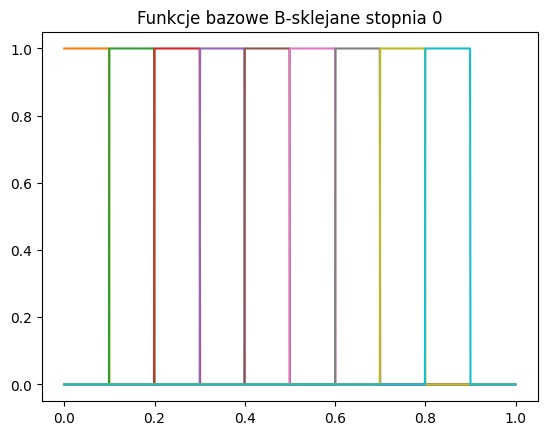

In [2]:
t = np.arange(0, 1, 0.001)
M = 10
T = []
for i in range(0, M + 1):
    T.append(0.1 * (i - 1))

poly1 = bspline0(T, t, M)
plt.plot(t, poly1)
plt.title("Funkcje bazowe B-sklejane stopnia 0")

# Unormowane wielomiany stopnia 1,2 i 3


Text(0.5, 1.0, 'Wielomiany B-sklejane stopnia 3')

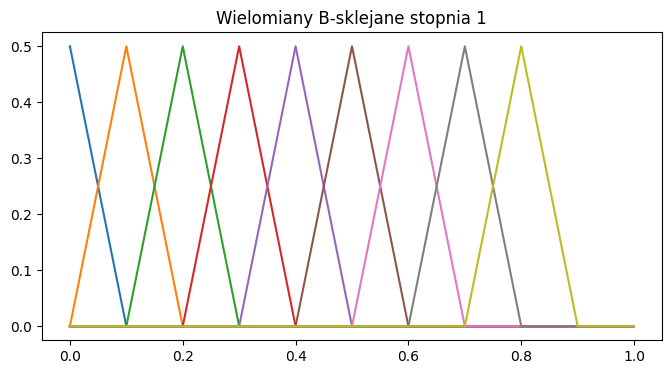

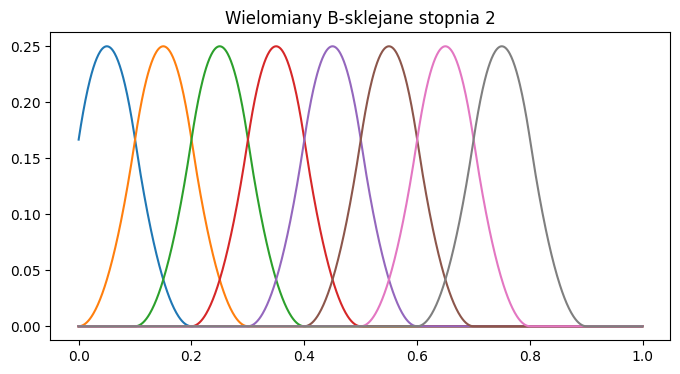

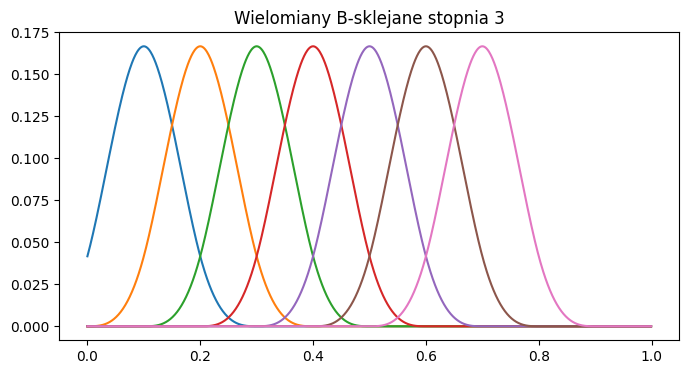

In [9]:
def bspline1(T, t, M):
    T = np.asarray(T)
    t = np.asarray(t)

    poly0 = bspline0(T, t, M)
    poly1 = np.zeros((t.size, M - 1))
    for j in range(M - 1):
        poly1[:, j] = ((t - T[j]) * poly0[:, j] + (T[j + 2] - t) * poly0[:, j + 1]) / (
            T[j + 2] - T[j]
        )
    return poly1


def bspline2(T, t, M):
    T = np.asarray(T)
    t = np.asarray(t)

    poly1 = bspline1(T, t, M)
    poly2 = np.zeros((t.size, M - 2))
    for j in range(M - 2):
        poly2[:, j] = ((t - T[j]) * poly1[:, j] + (T[j + 3] - t) * poly1[:, j + 1]) / (
            T[j + 3] - T[j]
        )
    return poly2


def bspline3(T, t, M):
    T = np.asarray(T)
    t = np.asarray(t)

    poly2 = bspline2(T, t, M)
    poly3 = np.zeros((t.size, M - 3))
    for j in range(M - 3):
        poly3[:, j] = ((t - T[j]) * poly2[:, j] + (T[j + 4] - t) * poly2[:, j + 1]) / (
            T[j + 4] - T[j]
        )
    return poly3


poly1 = bspline1(T, t, M)
plt.figure(figsize=(8, 4))
plt.plot(t, poly1)
plt.title("Wielomiany B-sklejane stopnia 1")

poly2 = bspline2(T, t, M)
plt.figure(figsize=(8, 4))
plt.plot(t, poly2)
plt.title("Wielomiany B-sklejane stopnia 2")

poly3 = bspline3(T, t, M)
plt.figure(figsize=(8, 4))
plt.plot(t, poly3)
plt.title("Wielomiany B-sklejane stopnia 3")

# Zadanie 3 - krzywa b-sklejana w 2D


Text(0.5, 1.0, 'Krzywa B-sklejana stopnia 2 w 2D')

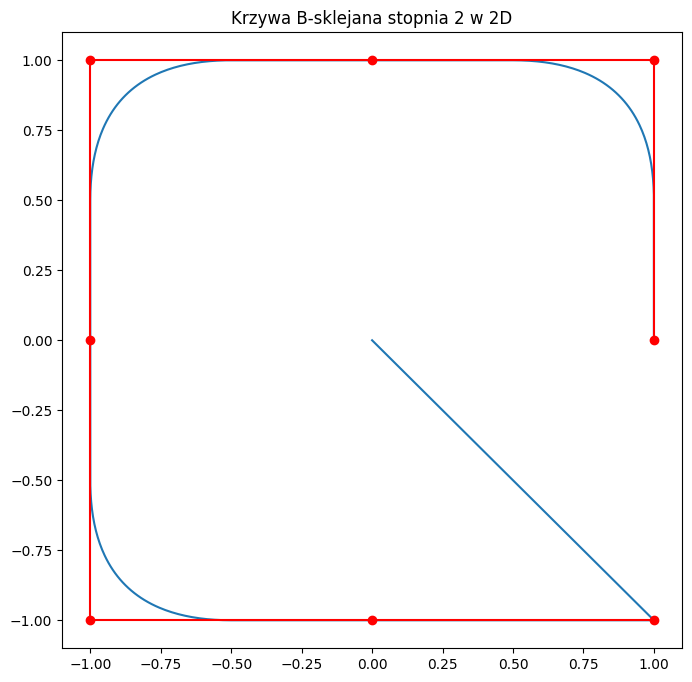

In [ ]:
control_points = np.array(
    [[1, 0], [1, 1], [0, 1], [-1, 1], [-1, 0], [-1, -1], [0, -1], [1, -1]]
)


def spline2D(poly, points):
    N, kk = poly.shape
    xx = np.zeros((N, 1))
    yy = np.zeros((N, 1))

    poly_sum = np.sum(poly, axis=1)
    poly_sum[poly_sum == 0] = 1

    for i in range(N):
        for j in range(kk):
            xx[i] += (poly[i, j] / poly_sum[i]) * points[j, 0]
            yy[i] += (poly[i, j] / poly_sum[i]) * points[j, 1]
    return xx, yy


poly2 = bspline2(T, t, M)
spline_x, spline_y = spline2D(poly2, control_points)
plt.figure(figsize=(8, 8))
plt.plot(spline_x, spline_y, label="Krzywa B-sklejana stopnia 2")
plt.plot(control_points[:, 0], control_points[:, 1], "ro-", label="Punkty kontrolne")
plt.title("Krzywa B-sklejana stopnia 2 w 2D")

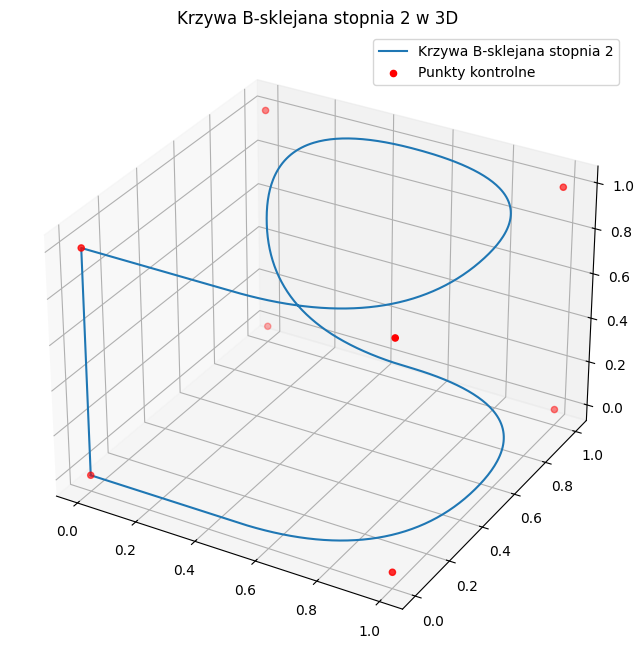

In [ ]:
points3D = np.array(
    [
        [0, 0, 0],
        [1, 0, 0],
        [1, 1, 0],
        [0, 1, 0],
        [0, 1, 1],
        [1, 1, 1],
        [1, 0, 1],
        [0, 0, 1],
    ]
)


def spline3D(poly, points):
    N, kk = poly.shape
    xx = np.zeros((N, 1))
    yy = np.zeros((N, 1))
    zz = np.zeros((N, 1))

    poly_sum = np.sum(poly, axis=1)
    poly_sum[poly_sum == 0] = 1

    for i in range(N):
        for j in range(kk):
            xx[i] += (poly[i, j] / poly_sum[i]) * points[j, 0]
            yy[i] += (poly[i, j] / poly_sum[i]) * points[j, 1]
            zz[i] += (poly[i, j] / poly_sum[i]) * points[j, 2]
    return xx, yy, zz


poly2 = bspline2(T, t, M)
spline_x, spline_y, spline_z = spline3D(poly2, points3D)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(
    spline_x.flatten(),
    spline_y.flatten(),
    spline_z.flatten(),
    label="Krzywa B-sklejana stopnia 2",
)
ax.scatter(
    points3D[:, 0],
    points3D[:, 1],
    points3D[:, 2],
    color="red",
    label="Punkty kontrolne",
)
ax.set_title("Krzywa B-sklejana stopnia 2 w 3D")
ax.legend()
